# SisFall — AFD-CNN Training Notebook (Fall Peaks, Random ADL Windows, Balanced Classes)

Same model and preprocessing as `SisFall_train_peak_balanced_v2.ipynb`, but the non-fall / ADL windows are selected randomly instead of by peak magnitude.

### Windowing strategy

**Fall class (label 0):** one window per recording, centred on the global-maximum peak of ‖a‖.  This matches the original peak-window approach for falls.

**Non-fall / ADL classes:** each recording contributes randomly positioned 2 s windows.  Random candidate windows are pooled by class, then each class is sampled to the same target count.

### Per-class balancing
| Situation | Action |
|---|---|
| candidates ≥ TARGET | randomly sample TARGET windows without replacement |
| candidates < TARGET | keep all + random oversample with replacement to reach TARGET |

TARGET = number of fall peak windows, capped by `TARGET_COUNT` (nominally 298), so every class ends up with exactly the same total count.  The train/test split is also done explicitly per class, so every label has the same number of train samples and the same number of test samples.

Checkpoint → `model/sisfall_fall_peak_random_balanced_model.ckpt`  
CSVs → `data/sisfall_fall_peak_random_balanced_{train,test}.csv`

**SisFall activity → class mapping:**

| SisFall codes | Class label | Activity |
|---|---|---|
| F01–F15 | 0 | **Fall** |
| D01, D02 | 2 | Walk |
| D03, D04 | 3 | Jog |
| D19 | 4 | Jump |
| D05 | 5 | Up-stairs |
| D06 | 6 | Down-stairs |
| D07, D08 | 7 | Stand→Sit |
| D09, D10 | 9 | Sit→Stand |


## 1. Setup

In [68]:
import sys, os
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)

import importlib, cnn as cnn_module
importlib.reload(cnn_module)

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)


TensorFlow version: 2.21.0
NumPy version: 2.4.4


## 2. Configuration

In [69]:
SISFALL_PATH    = 'SisFall_dataset'
MODEL_SAVE_PATH = 'model/sisfall_fall_peak_random_balanced_model.ckpt'
TRAIN_CSV       = 'data/sisfall_fall_peak_random_balanced_train.csv'
TEST_CSV        = 'data/sisfall_fall_peak_random_balanced_test.csv'

CLASS_LIST  = [0, 2, 3, 4, 5, 6, 7, 9]
CLASS_NUM   = len(CLASS_LIST)
CLASS_NAMES = {
    0: 'Fall', 2: 'Walk', 3: 'Jog', 4: 'Jump',
    5: 'Up-stairs', 6: 'Down-stairs', 7: 'Stand→Sit', 9: 'Sit→Stand'
}

CODE_TO_LABEL = {
    **{f'F{i:02d}': 0 for i in range(1, 16)},
    'D01': 2, 'D02': 2,
    'D03': 3, 'D04': 3,
    'D19': 4,
    'D05': 5,
    'D06': 6,
    'D07': 7, 'D08': 7,
    'D09': 9, 'D10': 9,
}

WINDOW      = 200   # 2 s at 100 Hz
HALF_WINDOW = WINDOW // 2

# Desired samples per class. The actual target is set to min(fall_count, TARGET_COUNT)
# after data collection so it always matches the available fall peak-window count.
TARGET_COUNT = 298

# Each non-fall recording contributes this many randomly positioned candidate windows.
# Increase this if a class reports oversampling and you want more unique ADL candidates.
RANDOM_WINDOWS_PER_RECORDING = 8

TEST_SIZE   = 0.20
RANDOM_SEED = 42

print('Classes:', CLASS_LIST)
print('Activity codes tracked:', sorted(CODE_TO_LABEL.keys()))
print(f'Configured target per class: {TARGET_COUNT}')
print(f'Random ADL windows per recording: {RANDOM_WINDOWS_PER_RECORDING}')


Classes: [0, 2, 3, 4, 5, 6, 7, 9]
Activity codes tracked: ['D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08', 'D09', 'D10', 'D19', 'F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15']
Configured target per class: 298
Random ADL windows per recording: 8


## 3. Helper Functions

In [70]:
def parse_sisfall_txt(filepath):
    """Read a SisFall .txt file → float32 array (N, 9) of raw ADC values."""
    rows = []
    with open(filepath) as f:
        for line in f:
            line = line.strip().rstrip(';')
            if not line:
                continue
            try:
                parts = [int(x.strip()) for x in line.split(',')]
                if len(parts) == 9:
                    rows.append(parts)
            except ValueError:
                pass
    return np.array(rows, dtype=np.float32) if rows else None


def normalize_adxl345(raw):
    """Map ADXL345 13-bit ADC values in [-4096, 4095] linearly to [0, 255]."""
    return np.clip((raw + 4096.0) / 8192.0 * 255.0, 0.0, 255.0)


def extract_peak_window(arr, window=200):
    """
    Single max-peak window from arr (T, 3).
    Returns (window_arr, peak_idx) or (None, None) if the recording is too short.
    """
    n = len(arr)
    if n < window:
        return None, None
    magnitude = np.linalg.norm(arr, axis=1)
    peak_idx  = int(np.argmax(magnitude))
    start     = max(0, min(peak_idx - window // 2, n - window))
    return arr[start:start + window], peak_idx


def extract_random_windows(arr, window=200, n_windows=8, rng=None):
    """
    Draw randomly positioned windows from arr (T, 3).

    Returns a list of (win_arr, start_idx).  Start positions are sampled without
    replacement when possible; if a very short recording has fewer possible start
    positions than requested windows, sampling falls back to replacement.
    """
    n = len(arr)
    if n < window or n_windows <= 0:
        return []

    if rng is None:
        rng = np.random.default_rng()

    n_possible = n - window + 1
    replace = n_windows > n_possible
    starts = rng.choice(n_possible, size=n_windows, replace=replace)

    return [(arr[int(start):int(start) + window].copy(), int(start)) for start in starts]


print('Helper functions defined.')


Helper functions defined.


## 4. Collect Random / Peak Windows and Balance Classes

Falls keep the peak-centred extraction.  Every non-fall label uses random 2 s candidate windows, then all labels are balanced to the same target count.


In [71]:
rng = np.random.default_rng(RANDOM_SEED)

skip_prefixes = {'desktop', 'Links', 'Readme'}

# ── Stage 1: collect candidate windows ────────────────────────────────────────
# Falls     → one max-peak window per recording
# Non-falls → RANDOM_WINDOWS_PER_RECORDING random windows per recording
candidate_windows = {lbl: [] for lbl in CLASS_LIST}  # label → [(flat_600, source_position)]
recording_counts  = {lbl: 0 for lbl in CLASS_LIST}

for subj in sorted(os.listdir(SISFALL_PATH)):
    subj_path = os.path.join(SISFALL_PATH, subj)
    if not os.path.isdir(subj_path):
        continue

    for fname in sorted(os.listdir(subj_path)):
        if not fname.endswith('.txt'):
            continue
        if any(fname.startswith(p) for p in skip_prefixes):
            continue

        code = fname.split('_')[0]
        if code not in CODE_TO_LABEL:
            continue

        label = CODE_TO_LABEL[code]

        raw = parse_sisfall_txt(os.path.join(subj_path, fname))
        if raw is None or len(raw) < WINDOW * 2:
            continue

        raw_ds  = raw[::2]        # downsample 200 Hz → 100 Hz
        acc_raw = raw_ds[:, 0:3]  # ADXL345 columns
        recording_counts[label] += 1

        if label == 0:
            win_raw, peak_idx = extract_peak_window(acc_raw, window=WINDOW)
            if win_raw is not None:
                candidate_windows[label].append(
                    (normalize_adxl345(win_raw).flatten().astype(np.float32), peak_idx)
                )
        else:
            for win_raw, start_idx in extract_random_windows(
                    acc_raw, window=WINDOW,
                    n_windows=RANDOM_WINDOWS_PER_RECORDING,
                    rng=rng):
                candidate_windows[label].append(
                    (normalize_adxl345(win_raw).flatten().astype(np.float32), start_idx)
                )

# ── Stage 2: balance every class to exactly TARGET samples ────────────────────
n_falls = len(candidate_windows[0])
TARGET  = min(n_falls, TARGET_COUNT)
if TARGET < 2:
    raise ValueError(f'Not enough fall windows to create a balanced split: TARGET={TARGET}')

print(f'Fall peak windows collected: {n_falls}  →  TARGET = {TARGET}')
print()

X_acc_list = []
y_list     = []
selection_summary = []

for lbl in CLASS_LIST:
    windows = list(candidate_windows[lbl])
    n_cand = len(windows)
    if n_cand == 0:
        raise ValueError(f'No candidate windows collected for class {lbl} ({CLASS_NAMES[lbl]})')

    if n_cand >= TARGET:
        chosen_idxs = rng.choice(n_cand, size=TARGET, replace=False)
        n_over = 0
    else:
        extra_idxs = rng.choice(n_cand, size=TARGET - n_cand, replace=True)
        chosen_idxs = np.concatenate([np.arange(n_cand), extra_idxs])
        n_over = TARGET - n_cand

    chosen_idxs = rng.permutation(chosen_idxs)
    for idx in chosen_idxs:
        win_flat, _ = windows[int(idx)]
        X_acc_list.append(win_flat)
        y_list.append(lbl)

    selection_summary.append((lbl, recording_counts[lbl], n_cand, TARGET, n_over))

X_acc = np.array(X_acc_list, dtype=np.float32)   # (N, 600)
y     = np.array(y_list, dtype=int)

print(f'Total windows after balancing: {len(X_acc)}')
print(f'Sensor value range: [{X_acc.min():.1f}, {X_acc.max():.1f}]')
print()
print(f'{"Class":>12s}  {"Recordings":>10}  {"Candidates":>11}  {"Kept":>6}  {"Oversampled":>12}')
print('-' * 64)
for lbl, n_rec, n_cand, n_kept, n_over in selection_summary:
    flag = '  ← oversampled' if n_over > 0 else ''
    print(f'{CLASS_NAMES[lbl]:>12s}  {n_rec:>10}  {n_cand:>11}  {n_kept:>6}  {n_over:>12}{flag}')


Fall peak windows collected: 1798  →  TARGET = 298

Total windows after balancing: 2384
Sensor value range: [6.5, 254.8]

       Class  Recordings   Candidates    Kept   Oversampled
----------------------------------------------------------------
        Fall        1798         1798     298             0
        Walk          76          608     298             0
         Jog          74          592     298             0
        Jump         120          960     298             0
   Up-stairs         190         1520     298             0
 Down-stairs         118          944     298             0
   Stand→Sit         380         3040     298             0
   Sit→Stand         370         2960     298             0


## 5. Visualise Fall Peak and Random ADL Window

One fall recording keeps the max-peak centred window.  One Walk recording shows a random 2 s window.


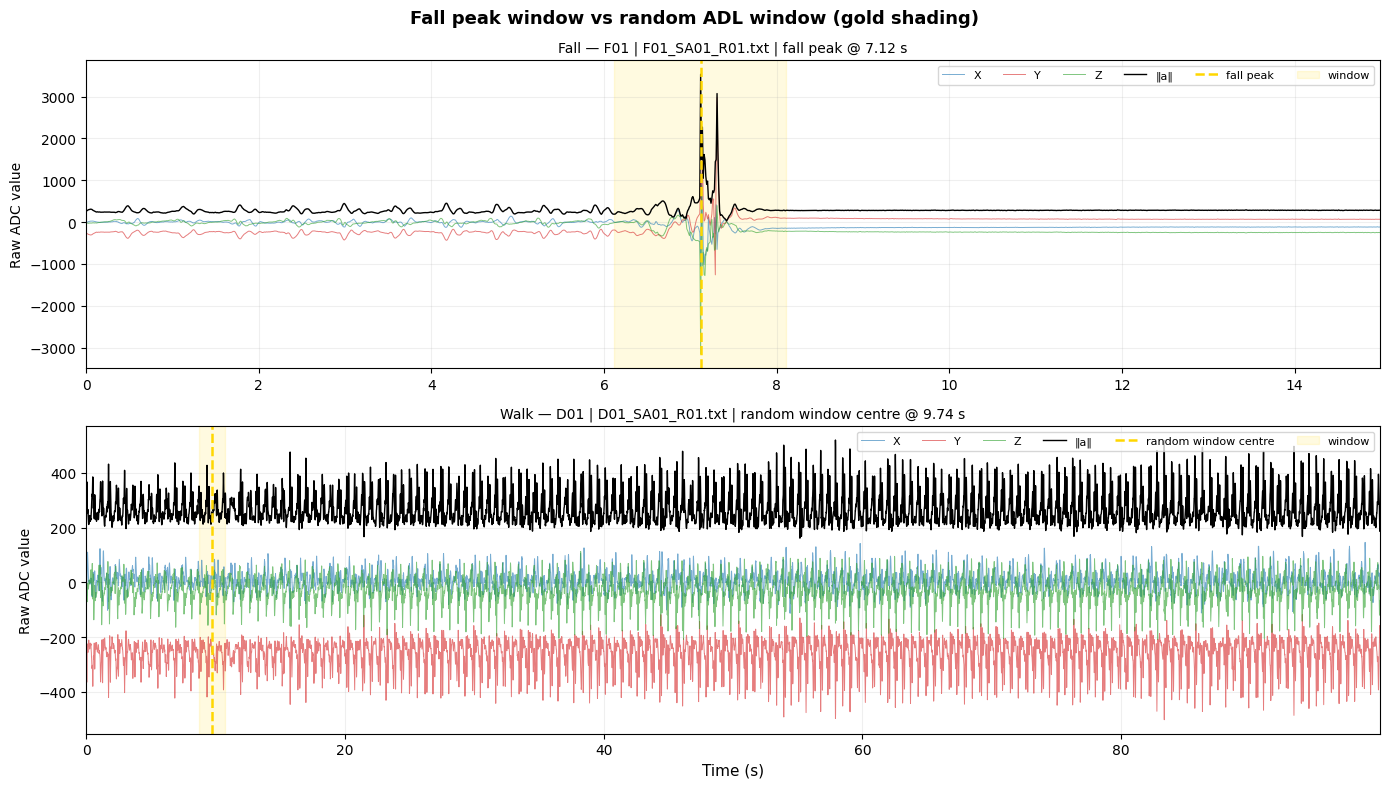

In [72]:
def load_window_for_vis(label_filter, code_filter=None, rng_seed=RANDOM_SEED):
    vis_rng = np.random.default_rng(rng_seed)
    for subj in sorted(os.listdir(SISFALL_PATH)):
        subj_path = os.path.join(SISFALL_PATH, subj)
        if not os.path.isdir(subj_path):
            continue
        for fname in sorted(os.listdir(subj_path)):
            if not fname.endswith('.txt'):
                continue
            code = fname.split('_')[0]
            if CODE_TO_LABEL.get(code) != label_filter:
                continue
            if code_filter and code != code_filter:
                continue
            raw = parse_sisfall_txt(os.path.join(subj_path, fname))
            if raw is None or len(raw) < WINDOW * 2:
                continue

            acc_raw = raw[::2][:, 0:3]
            if label_filter == 0:
                _, peak_idx = extract_peak_window(acc_raw, window=WINDOW)
                start_idx = max(0, min(peak_idx - HALF_WINDOW, len(acc_raw) - WINDOW))
                marker_idx = peak_idx
                marker_label = 'fall peak'
            else:
                random_windows = extract_random_windows(acc_raw, window=WINDOW, n_windows=1, rng=vis_rng)
                if not random_windows:
                    continue
                _, start_idx = random_windows[0]
                marker_idx = start_idx + HALF_WINDOW
                marker_label = 'random window centre'

            return acc_raw, marker_idx, start_idx, marker_label, fname
    return None, None, None, None, None


fig, axes = plt.subplots(2, 1, figsize=(14, 8))
AXIS_COLORS = ['#1f77b4', '#d62728', '#2ca02c']

for ax, (lbl, code_f, title_tag) in zip(axes, [
        (0, 'F01', 'Fall — F01'),
        (2, 'D01', 'Walk — D01'),
]):
    acc_raw, marker_idx, start_idx, marker_label, fname = load_window_for_vis(lbl, code_f)
    if acc_raw is None:
        ax.set_title(f'{title_tag}: no file found')
        continue
    t   = np.arange(len(acc_raw)) / 100.0
    mag = np.linalg.norm(acc_raw, axis=1)
    for i, (aname, color) in enumerate(zip(['X', 'Y', 'Z'], AXIS_COLORS)):
        ax.plot(t, acc_raw[:, i], color=color, linewidth=0.7, alpha=0.6, label=aname)
    ax.plot(t, mag, color='black', linewidth=1.0, label='‖a‖')
    ax.axvline(t[marker_idx], color='gold', linewidth=1.8, linestyle='--', label=marker_label)
    ax.axvspan(t[start_idx], t[start_idx + WINDOW - 1], alpha=0.12, color='gold', label='window')
    ax.set_xlim(0, t[-1])
    ax.set_title(f'{title_tag} | {fname} | {marker_label} @ {t[marker_idx]:.2f} s', fontsize=10)
    ax.set_ylabel('Raw ADC value')
    ax.legend(loc='upper right', fontsize=8, ncol=6)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time (s)', fontsize=11)
fig.suptitle('Fall peak window vs random ADL window (gold shading)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5b. Visualise Random ADL Window Sampling

Random windows from one Walk recording, colour-coded by draw order.


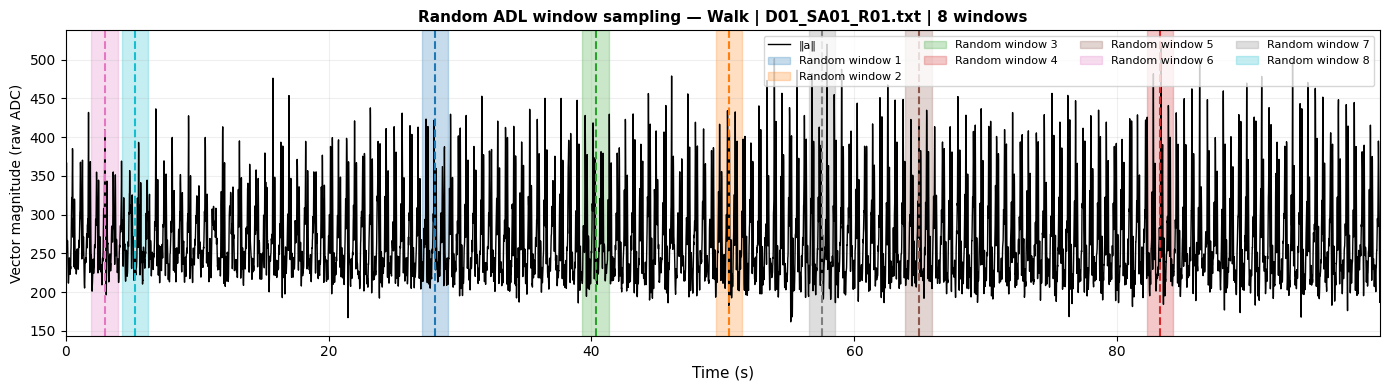

Random starts (s): ['27.10', '49.49', '39.31', '82.25', '63.89', '1.96', '56.54', '4.28']


In [73]:
demo_acc_raw, demo_windows, demo_fname = None, [], ''
vis_rng = np.random.default_rng(RANDOM_SEED + 1)

for subj in sorted(os.listdir(SISFALL_PATH)):
    subj_path = os.path.join(SISFALL_PATH, subj)
    if not os.path.isdir(subj_path):
        continue
    for fname in sorted(os.listdir(subj_path)):
        if not fname.endswith('.txt'):
            continue
        if fname.split('_')[0] not in ('D01', 'D02'):
            continue
        raw = parse_sisfall_txt(os.path.join(subj_path, fname))
        if raw is None or len(raw) < WINDOW * 2:
            continue
        acc_raw = raw[::2][:, 0:3]
        windows = extract_random_windows(
            acc_raw, window=WINDOW,
            n_windows=min(RANDOM_WINDOWS_PER_RECORDING, 8),
            rng=vis_rng,
        )
        if len(windows) >= 2:
            demo_acc_raw, demo_windows, demo_fname = acc_raw, windows, fname
            break
    if demo_acc_raw is not None:
        break

if demo_acc_raw is None:
    print('No suitable Walk recording found.')
else:
    t   = np.arange(len(demo_acc_raw)) / 100.0
    mag = np.linalg.norm(demo_acc_raw, axis=1)
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(t, mag, color='black', linewidth=1.0, label='‖a‖')

    colors_win = plt.cm.tab10(np.linspace(0, 0.9, len(demo_windows)))
    for rank, ((_, start_idx), color) in enumerate(zip(demo_windows, colors_win)):
        ax.axvspan(t[start_idx], t[start_idx + WINDOW - 1], alpha=0.25, color=color,
                   label=f'Random window {rank + 1}')
        ax.axvline(t[start_idx + HALF_WINDOW], color=color, linewidth=1.5, linestyle='--')

    ax.set_xlim(0, t[-1])
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Vector magnitude (raw ADC)', fontsize=10)
    ax.set_title(
        f'Random ADL window sampling — Walk | {demo_fname} | {len(demo_windows)} windows',
        fontsize=11, fontweight='bold'
    )
    ax.legend(loc='upper right', fontsize=8, ncol=4)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
    print('Random starts (s):', [f'{start / 100.0:.2f}' for _, start in demo_windows])


## 6. Visualise Sample Windows

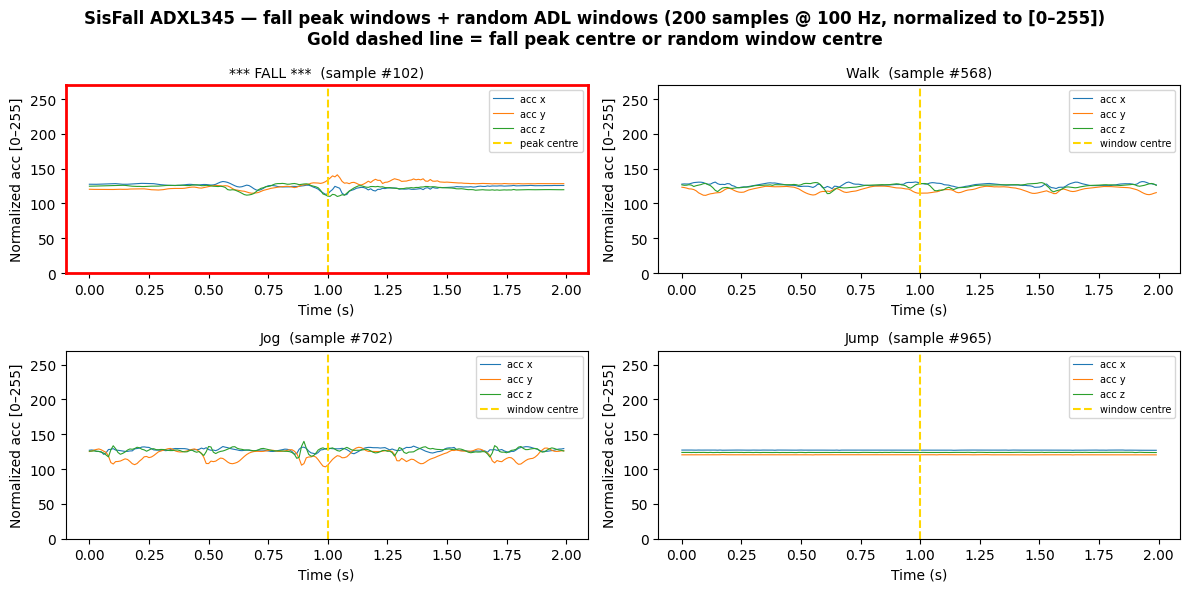

In [74]:
np.random.seed(RANDOM_SEED)
show_labels = [0, 2, 3, 4]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']

for ax, label in zip(axes.flat, show_labels):
    idxs     = np.where(y == label)[0]
    sample_i = idxs[np.random.randint(len(idxs))]
    acc_data = X_acc[sample_i].reshape(200, 3)
    t        = np.arange(200) / 100.0
    for i, (aname, color) in enumerate(zip(['x', 'y', 'z'], colors)):
        ax.plot(t, acc_data[:, i], color=color, linewidth=0.8, label=f'acc {aname}')
    line_label = 'peak centre' if label == 0 else 'window centre'
    ax.axvline(1.0, color='gold', linewidth=1.5, linestyle='--', label=line_label)
    tag = '*** FALL ***' if label == 0 else CLASS_NAMES[label]
    ax.set_title(f'{tag}  (sample #{sample_i})', fontsize=10)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Normalized acc [0–255]')
    ax.legend(fontsize=7)
    ax.set_ylim(0, 270)
    if label == 0:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2)

fig.suptitle(
    'SisFall ADXL345 — fall peak windows + random ADL windows (200 samples @ 100 Hz, normalized to [0–255])\n'
    'Gold dashed line = fall peak centre or random window centre',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()


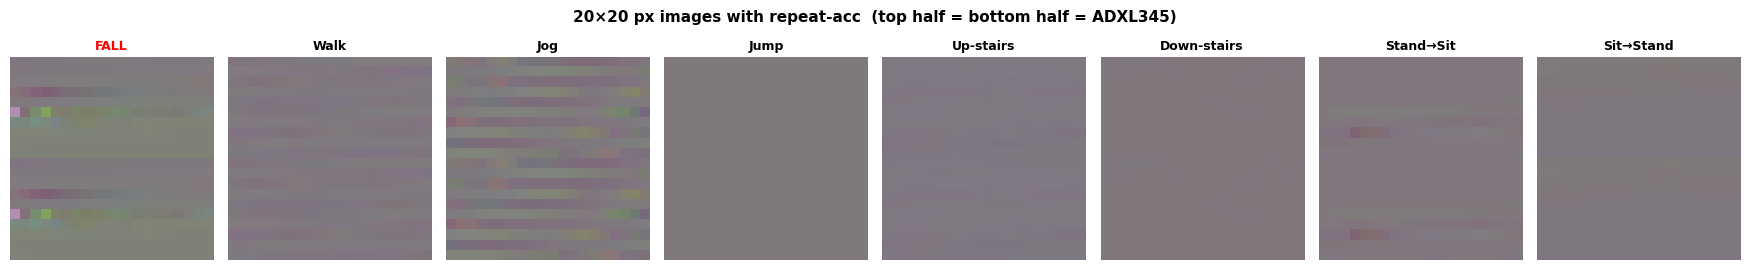

In [75]:
def to_image_repeat(acc_flat):
    repeated = np.concatenate([acc_flat, acc_flat])
    return repeated.reshape(20, 20, 3) / 255.0

np.random.seed(7)
fig, axes = plt.subplots(1, len(CLASS_LIST), figsize=(2.2 * len(CLASS_LIST), 2.8))
for ax, label in zip(axes, CLASS_LIST):
    idxs     = np.where(y == label)[0]
    sample_i = idxs[np.random.randint(len(idxs))]
    ax.imshow(to_image_repeat(X_acc[sample_i]))
    tag = 'FALL' if label == 0 else CLASS_NAMES[label]
    ax.set_title(tag, fontsize=9, color='red' if label == 0 else 'black', fontweight='bold')
    ax.axis('off')

fig.suptitle('20\u00d720 px images with repeat-acc  (top half = bottom half = ADXL345)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

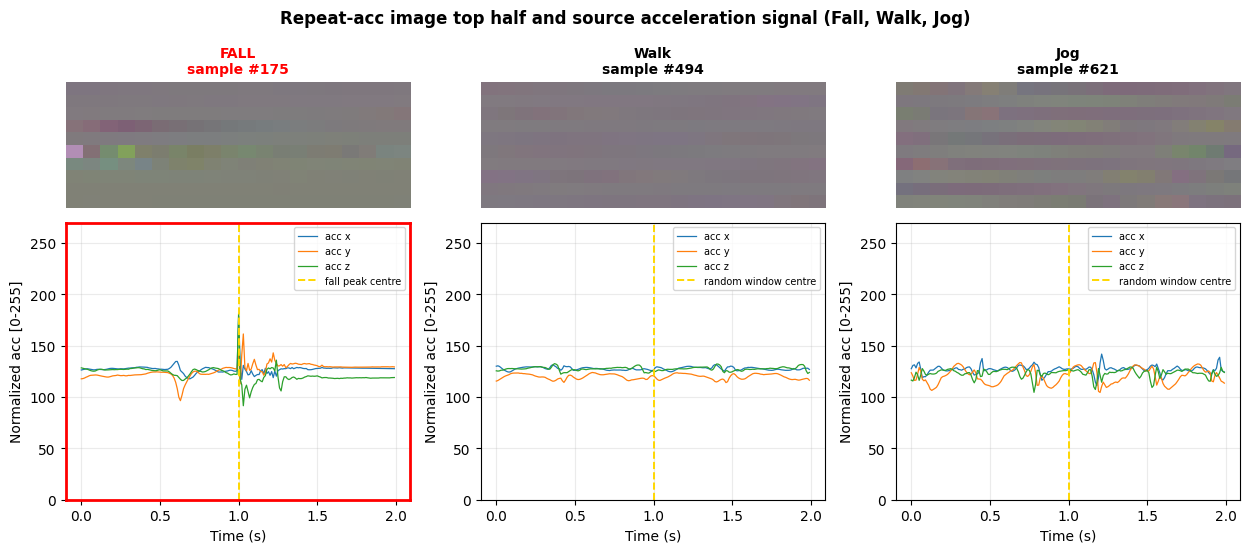

In [76]:
# Fall / Walk / Jog: top half of repeat-acc image with its source time signal below.
plot_labels = [0, 2, 3]
np.random.seed(7)

fig, axes = plt.subplots(
    2, len(plot_labels), figsize=(4.2 * len(plot_labels), 5.6),
    gridspec_kw={'height_ratios': [1, 2.2]},
)
axis_colors = ['tab:blue', 'tab:orange', 'tab:green']

for col, label in enumerate(plot_labels):
    idxs = np.where(y == label)[0]
    sample_i = idxs[np.random.randint(len(idxs))]

    image_top = to_image_repeat(X_acc[sample_i])[:10, :, :]
    acc_data = X_acc[sample_i].reshape(WINDOW, 3)
    t = np.arange(WINDOW) / 100.0

    ax_img = axes[0, col]
    ax_sig = axes[1, col]

    tag = 'FALL' if label == 0 else CLASS_NAMES[label]
    title_color = 'red' if label == 0 else 'black'
    ax_img.imshow(image_top, aspect='auto')
    ax_img.set_title(f'{tag}\nsample #{sample_i}', fontsize=10,
                     color=title_color, fontweight='bold')
    ax_img.axis('off')

    for axis_idx, (aname, color) in enumerate(zip(['x', 'y', 'z'], axis_colors)):
        ax_sig.plot(t, acc_data[:, axis_idx], color=color, linewidth=0.9, label=f'acc {aname}')

    marker_label = 'fall peak centre' if label == 0 else 'random window centre'
    ax_sig.axvline(1.0, color='gold', linewidth=1.4, linestyle='--', label=marker_label)
    ax_sig.set_xlabel('Time (s)')
    ax_sig.set_ylabel('Normalized acc [0-255]')
    ax_sig.set_ylim(0, 270)
    ax_sig.grid(True, alpha=0.25)
    ax_sig.legend(fontsize=7, loc='upper right')

    if label == 0:
        for spine in ax_sig.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2)

fig.suptitle(
    'Repeat-acc image top half and source acceleration signal (Fall, Walk, Jog)',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()


## 7. Equal Per-Class Train / Test Split and Save CSVs

The split is performed independently within each label.  This keeps every category balanced in the training CSV and every category balanced in the test CSV.


In [77]:
split_rng = np.random.default_rng(RANDOM_SEED)

TEST_PER_CLASS = int(round(TARGET * TEST_SIZE))
TEST_PER_CLASS = max(1, min(TARGET - 1, TEST_PER_CLASS))
TRAIN_PER_CLASS = TARGET - TEST_PER_CLASS

train_indices = []
test_indices  = []

for lbl in CLASS_LIST:
    idxs = np.where(y == lbl)[0]
    if len(idxs) != TARGET:
        raise ValueError(f'Class {lbl} has {len(idxs)} samples; expected TARGET={TARGET}')

    idxs = split_rng.permutation(idxs)
    test_indices.extend(idxs[:TEST_PER_CLASS])
    train_indices.extend(idxs[TEST_PER_CLASS:TEST_PER_CLASS + TRAIN_PER_CLASS])

idx_train = split_rng.permutation(np.array(train_indices, dtype=int))
idx_test  = split_rng.permutation(np.array(test_indices, dtype=int))

X_acc_train, X_acc_test = X_acc[idx_train], X_acc[idx_test]
y_train,     y_test     = y[idx_train],     y[idx_test]

print(f'Train: {len(X_acc_train)} samples | Test: {len(X_acc_test)} samples')
print(f'Per class: train={TRAIN_PER_CLASS}, test={TEST_PER_CLASS}')
print()
print(f'{"Class":>12s}  {"Train":>7}  {"Test":>6}')
print('-' * 32)
for lbl in CLASS_LIST:
    print(f'{CLASS_NAMES[lbl]:>12s}  {(y_train == lbl).sum():>7}  {(y_test == lbl).sum():>6}')


Train: 1904 samples | Test: 480 samples
Per class: train=238, test=60

       Class    Train    Test
--------------------------------
        Fall      238      60
        Walk      238      60
         Jog      238      60
        Jump      238      60
   Up-stairs      238      60
 Down-stairs      238      60
   Stand→Sit      238      60
   Sit→Stand      238      60


In [78]:
col_names = ['label'] + [str(i + 1) for i in range(600)]

train_df = pd.DataFrame(np.column_stack([y_train.astype(float), X_acc_train]), columns=col_names)
train_df['label'] = y_train
train_df.to_csv(TRAIN_CSV, index=False)

test_df = pd.DataFrame(np.column_stack([y_test.astype(float), X_acc_test]), columns=col_names)
test_df['label'] = y_test
test_df.to_csv(TEST_CSV, index=False)

print(f'Saved  {TRAIN_CSV}  ({len(train_df)} rows)')
print(f'Saved  {TEST_CSV}   ({len(test_df)} rows)')

Saved  data/sisfall_fall_peak_random_balanced_train.csv  (1904 rows)
Saved  data/sisfall_fall_peak_random_balanced_test.csv   (480 rows)


## 8. Build Model Inputs (Apply Repeat-Acc)

The model expects 1200 values. Repeat-acc: `[acc_600, acc_600]`.

In [79]:
def apply_repeat_acc(X_600):
    return np.hstack([X_600, X_600]).astype(np.float32)

def to_onehot(labels_arr, class_list):
    y_oh = np.zeros((len(labels_arr), len(class_list)), dtype=np.float32)
    for i, lbl in enumerate(labels_arr):
        y_oh[i, class_list.index(lbl)] = 1.0
    return y_oh

X_model_train = apply_repeat_acc(X_acc_train)
X_model_test  = apply_repeat_acc(X_acc_test)
y_train_oh    = to_onehot(y_train, CLASS_LIST)
y_test_oh     = to_onehot(y_test,  CLASS_LIST)

print(f'Train input: {X_model_train.shape}  |  Test input: {X_model_test.shape}')
print(f'Value range: [{X_model_train.min():.1f}, {X_model_train.max():.1f}]')

Train input: (1904, 1200)  |  Test input: (480, 1200)
Value range: [6.7, 254.8]


## 9. Build TF Graph and Train

In [80]:
TRAIN_STEPS   = 5000
BATCH_SIZE    = 50
LEARNING_RATE = 0.001

tf.reset_default_graph()

x_ph = tf.placeholder(tf.float32, [None, 1200], name='input')
y_ph = tf.placeholder(tf.float32, [None, CLASS_NUM], name='labels')

logits, keep_prob_ph = cnn_module.fall_net(x_ph)

loss_op    = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(labels=y_ph, logits=logits))
train_op   = tf.train.AdamOptimizer(LEARNING_RATE).minimize(loss_op)
correct_op = tf.equal(tf.argmax(logits, 1), tf.argmax(y_ph, 1))
acc_op     = tf.reduce_mean(tf.cast(correct_op, tf.float32))
probs_op   = tf.nn.softmax(logits)

saver = tf.train.Saver()
sess  = tf.Session()
sess.run(tf.global_variables_initializer())

print(f'Graph built. Training on {len(X_model_train)} samples for {TRAIN_STEPS} steps...')

Graph built. Training on 1904 samples for 5000 steps...


In [81]:
n_train = len(X_model_train)
perm    = np.random.permutation(n_train)
ptr     = 0

log_steps, log_loss, log_acc = [], [], []

for step in range(1, TRAIN_STEPS + 1):
    if ptr + BATCH_SIZE > n_train:
        perm = np.random.permutation(n_train)
        ptr  = 0
    batch_idx = perm[ptr:ptr + BATCH_SIZE]
    ptr += BATCH_SIZE

    _, loss_val = sess.run([train_op, loss_op],
                           feed_dict={x_ph: X_model_train[batch_idx],
                                      y_ph: y_train_oh[batch_idx],
                                      keep_prob_ph: 0.5})
    if step % 500 == 0:
        acc_val = acc_op.eval(session=sess,
                              feed_dict={x_ph: X_model_train[batch_idx],
                                         y_ph: y_train_oh[batch_idx],
                                         keep_prob_ph: 1.0})
        log_steps.append(step)
        log_loss.append(loss_val)
        log_acc.append(acc_val)
        print(f'Step {step:5d}  |  loss = {loss_val:.4f}  |  batch acc = {acc_val:.4f}')

save_path = saver.save(sess, MODEL_SAVE_PATH)
print(f'\nModel saved to {save_path}')

Step   500  |  loss = 0.8394  |  batch acc = 0.6800
Step  1000  |  loss = 0.5678  |  batch acc = 0.8000
Step  1500  |  loss = 0.6188  |  batch acc = 0.6800
Step  2000  |  loss = 0.4457  |  batch acc = 0.8400
Step  2500  |  loss = 0.3354  |  batch acc = 0.9000
Step  3000  |  loss = 0.3443  |  batch acc = 0.8200
Step  3500  |  loss = 0.3040  |  batch acc = 0.8600
Step  4000  |  loss = 0.2005  |  batch acc = 0.9200
Step  4500  |  loss = 0.1023  |  batch acc = 0.9800
Step  5000  |  loss = 0.2895  |  batch acc = 0.9000

Model saved to model/sisfall_fall_peak_random_balanced_model.ckpt


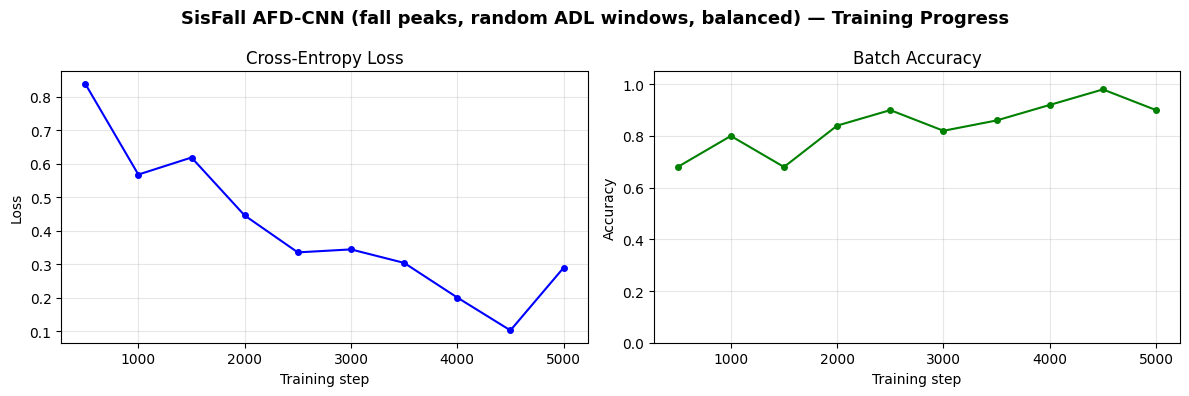

In [82]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(log_steps, log_loss, 'b-o', markersize=4)
ax1.set_title('Cross-Entropy Loss')
ax1.set_xlabel('Training step')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(log_steps, log_acc, 'g-o', markersize=4)
ax2.set_title('Batch Accuracy')
ax2.set_xlabel('Training step')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

fig.suptitle('SisFall AFD-CNN (fall peaks, random ADL windows, balanced) — Training Progress',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Evaluate on Train and Test Sets

In [83]:
def run_inference(X):
    EVAL_BATCH = 256
    all_logits = []
    all_probs  = []
    for start in range(0, len(X), EVAL_BATCH):
        l, p = sess.run([logits, probs_op],
                        feed_dict={x_ph: X[start:start + EVAL_BATCH], keep_prob_ph: 1.0})
        all_logits.append(l)
        all_probs.append(p)
    all_logits = np.vstack(all_logits)
    all_probs  = np.vstack(all_probs)
    pred_idx    = np.argmax(all_probs, axis=1)
    pred_labels = np.array([CLASS_LIST[i] for i in pred_idx])
    return pred_labels, all_probs, all_logits


for split_name, X_split, y_split in [
        ('Train', X_model_train, y_train),
        ('Test',  X_model_test,  y_test)]:

    pred_labels, _, _ = run_inference(X_split)
    overall = np.mean(pred_labels == y_split)

    print(f'=== {split_name} set ({len(y_split)} samples) ===')
    print(f'Overall accuracy: {overall:.4f}  ({overall:.2%})')
    print(f'{"Class":>12s}  {"N":>5}  {"Sensitivity":>12}  {"Specificity":>12}')
    print('-' * 48)
    for lbl in CLASS_LIST:
        acc, sens, spec = cnn_module.evaluate(pred_labels, y_split, lbl)
        n_cls = int((y_split == lbl).sum())
        print(f'{CLASS_NAMES[lbl]:>12s}  {n_cls:>5}  {sens:>12.4f}  {spec:>12.4f}')
    print()

=== Train set (1904 samples) ===
Overall accuracy: 0.9149  (91.49%)
       Class      N   Sensitivity   Specificity
------------------------------------------------
        Fall    238        1.0000        1.0000
        Walk    238        0.9958        1.0000
         Jog    238        1.0000        1.0000
        Jump    238        0.9244        0.9706
   Up-stairs    238        0.9412        1.0000
 Down-stairs    238        0.7437        0.9868
   Stand→Sit    238        0.9202        0.9466
   Sit→Stand    238        0.7941        0.9988

=== Test set (480 samples) ===
Overall accuracy: 0.7438  (74.38%)
       Class      N   Sensitivity   Specificity
------------------------------------------------
        Fall     60        0.9833        1.0000
        Walk     60        0.8833        0.9833
         Jog     60        0.9333        0.9905
        Jump     60        0.8167        0.9429
   Up-stairs     60        0.7500        0.9738
 Down-stairs     60        0.4500        0.9738

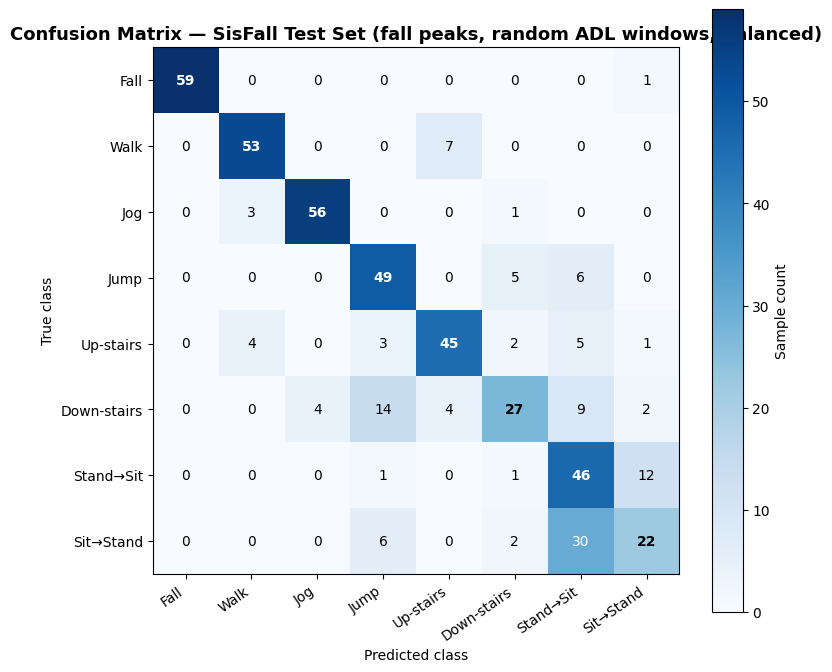

Evaluation complete. Session remains open for the final fall-score distribution cell.
Checkpoint: model/sisfall_fall_peak_random_balanced_model.ckpt
Test CSV:   data/sisfall_fall_peak_random_balanced_test.csv


In [84]:
pred_test, _, _ = run_inference(X_model_test)
label_names  = [CLASS_NAMES[l] for l in CLASS_LIST]
cm = confusion_matrix(y_test, pred_test, labels=CLASS_LIST)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax, label='Sample count')
ax.set_xticks(range(len(CLASS_LIST)))
ax.set_yticks(range(len(CLASS_LIST)))
ax.set_xticklabels(label_names, rotation=35, ha='right')
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_title('Confusion Matrix — SisFall Test Set (fall peaks, random ADL windows, balanced)',
             fontsize=13, fontweight='bold')
for i in range(len(CLASS_LIST)):
    for j in range(len(CLASS_LIST)):
        val    = cm[i, j]
        color  = 'white' if val > cm.max() / 2 else 'black'
        weight = 'bold' if i == j else 'normal'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=10, color=color, fontweight=weight)

plt.tight_layout()
plt.show()


print('Evaluation complete. Session remains open for the final fall-score distribution cell.')
print(f'Checkpoint: {MODEL_SAVE_PATH}')
print(f'Test CSV:   {TEST_CSV}')


## 11. Fall Logit and P(Fall) Distributions by True Label

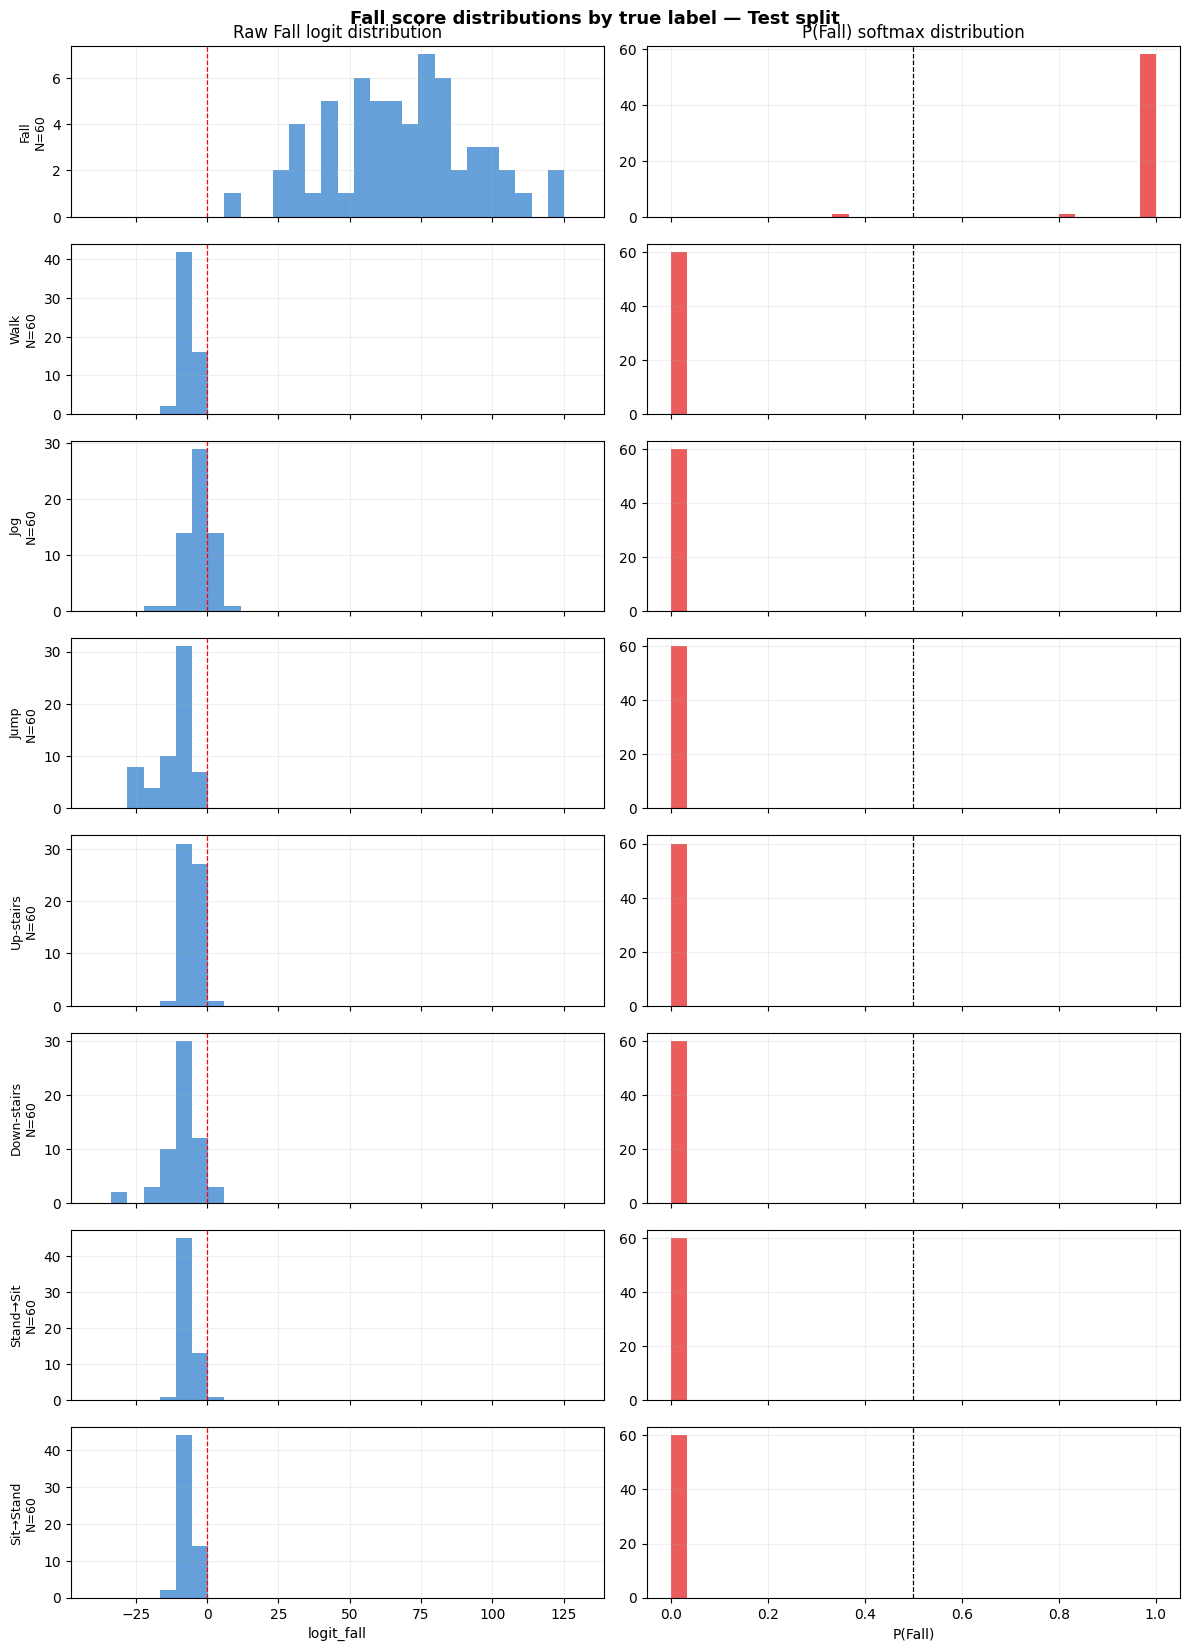

=== Fall score distribution summary ===
 label  class_name  n  mean_logit_fall  median_logit_fall  mean_prob_fall  median_prob_fall  max_prob_fall
     0        Fall 60        68.400055          69.023674        0.986188      9.999999e-01       1.000000
     2        Walk 60        -6.605997          -7.080962        0.000021      1.868680e-08       0.000544
     3         Jog 60        -2.565302          -2.751474        0.000002      3.191530e-14       0.000111
     4        Jump 60       -10.939851          -7.828805        0.000024      6.978162e-10       0.000659
     5   Up-stairs 60        -5.605318          -5.475135        0.000131      1.612457e-07       0.006432
     6 Down-stairs 60        -8.089339          -6.498605        0.000126      4.339443e-06       0.004522
     7   Stand→Sit 60        -6.073714          -6.153553        0.000081      1.350348e-06       0.002373
     9   Sit→Stand 60        -6.549081          -6.423553        0.000025      1.086176e-06       0.0004

In [85]:
# Distribution of raw Fall logits and P(Fall), separated by true label.
DIST_SPLIT = 'Test'
X_dist = X_model_test if DIST_SPLIT == 'Test' else X_model_train
y_dist = y_test if DIST_SPLIT == 'Test' else y_train

_, dist_probs, dist_logits = run_inference(X_dist)
fall_idx = CLASS_LIST.index(0)

dist_df = pd.DataFrame({
    'label': y_dist,
    'class_name': [CLASS_NAMES[int(lbl)] for lbl in y_dist],
    'logit_fall': dist_logits[:, fall_idx],
    'prob_fall': dist_probs[:, fall_idx],
})

logit_min, logit_max = dist_df['logit_fall'].min(), dist_df['logit_fall'].max()
if np.isclose(logit_min, logit_max):
    logit_min -= 1.0
    logit_max += 1.0
logit_pad = 0.05 * (logit_max - logit_min)
logit_bins = np.linspace(logit_min - logit_pad, logit_max + logit_pad, 31)
prob_bins = np.linspace(0.0, 1.0, 31)

fig, axes = plt.subplots(len(CLASS_LIST), 2, figsize=(12, 2.1 * len(CLASS_LIST)), sharex='col')
if len(CLASS_LIST) == 1:
    axes = np.array([axes])

for row_idx, lbl in enumerate(CLASS_LIST):
    cls = dist_df[dist_df['label'] == lbl]
    ax_logit, ax_prob = axes[row_idx]

    ax_logit.hist(cls['logit_fall'], bins=logit_bins, color='#4a8fd4', alpha=0.85)
    ax_logit.axvline(0, color='red', ls='--', lw=0.9)
    ax_logit.set_ylabel(f'{CLASS_NAMES[lbl]}\nN={len(cls)}', fontsize=9)
    ax_logit.grid(True, alpha=0.2)

    ax_prob.hist(cls['prob_fall'], bins=prob_bins, color='#e84040', alpha=0.85)
    ax_prob.axvline(0.5, color='black', ls='--', lw=0.9)
    ax_prob.grid(True, alpha=0.2)

axes[0, 0].set_title('Raw Fall logit distribution')
axes[0, 1].set_title('P(Fall) softmax distribution')
axes[-1, 0].set_xlabel('logit_fall')
axes[-1, 1].set_xlabel('P(Fall)')
fig.suptitle(f'Fall score distributions by true label — {DIST_SPLIT} split',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

summary = (dist_df
    .groupby(['label', 'class_name'])
    .agg(n=('prob_fall', 'size'),
         mean_logit_fall=('logit_fall', 'mean'),
         median_logit_fall=('logit_fall', 'median'),
         mean_prob_fall=('prob_fall', 'mean'),
         median_prob_fall=('prob_fall', 'median'),
         max_prob_fall=('prob_fall', 'max'))
    .reset_index())

print('=== Fall score distribution summary ===')
print(summary.to_string(index=False))

sess.close()
print('Training complete. Session closed.')
print(f'Checkpoint: {MODEL_SAVE_PATH}')
print(f'Test CSV:   {TEST_CSV}')
